# Упражнение 7.10. Задача предсказания с разделённой стратегией

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 7 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch07.pdf).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

N = 19           # число нетерминальных состояний (1..19), терминалы 0 и 20
GAMMA = 1.0
B_RIGHT = 0.5    # b(вправо) -- равновероятная стратегия

## Истинные ценности

Для фиксированной $\pi$ ценности решают линейную систему Беллмана
$v = r_\pi + \gamma P_\pi v$. Считаем её точно для каждого $p$.

In [2]:
def true_values(p_right):
    # Решаем (I - gamma P_pi) v = r_pi напрямую.
    A = np.eye(N)
    b = np.zeros(N)
    for i in range(1, N + 1):
        s = i - 1
        # шаг вправо с вероятностью p_right
        ns = i + 1
        r = 1.0 if ns == N + 1 else 0.0
        if 1 <= ns <= N:
            A[s, ns - 1] -= GAMMA * p_right
        b[s] += p_right * r
        # шаг влево с вероятностью 1 - p_right
        pl = 1 - p_right
        ns = i - 1
        r = -1.0 if ns == 0 else 0.0
        if 1 <= ns <= N:
            A[s, ns - 1] -= GAMMA * pl
        b[s] += pl * r
    return np.linalg.solve(A, b)

for p in (0.1, 0.3, 0.5):
    v = true_values(p)
    print(f"p={p}: v_min={v.min():.3f}, v_center={v[N//2]:.3f}, v_max={v.max():.3f}")

p=0.1: v_min=-1.000, v_center=-1.000, v_max=-0.778
p=0.3: v_min=-1.000, v_center=-1.000, v_max=-0.143
p=0.5: v_min=-0.900, v_center=0.000, v_max=0.900


## Генерация эпизода и коэффициент выборки по значимости

Эпизод всегда стартует из центра. Действия берём из равновероятной $b$.
Коэффициент $\rho = \pi(a|s)/b(a|s)$ зависит только от направления:
вправо даёт $p/0.5$, влево даёт $(1-p)/0.5$.

In [3]:
def gen_episode(rng):
    s = N // 2 + 1            # центральное состояние
    states = [s]
    rewards = [0.0]           # rewards[k] -- награда за переход в states[k]
    actions = []
    while True:
        a = 1 if rng.random() < B_RIGHT else -1
        actions.append(a)
        ns = s + a
        if ns == 0:
            rewards.append(-1.0); states.append(ns); break
        if ns == N + 1:
            rewards.append(1.0); states.append(ns); break
        rewards.append(0.0); states.append(ns); s = ns
    return states, actions, rewards

def rho_step(a, p):
    return (p / B_RIGHT) if a == 1 else ((1 - p) / B_RIGHT)

## Два алгоритма

В обычной версии (7.9) доход собирается вперёд, а вес $\rho_{\tau:\tau+n-1}$
умножается снаружи. В версии с control variate доход (7.13) считается рекурсией
от конца окна назад: в каждой точке вместо обнуления цель подставляет текущую
оценку $V(S_k)$ через слагаемое $(1-\rho_k)V(S_k)$.

In [4]:
def n_step_offpolicy(p, n, alpha, episodes, rng, control_variate):
    V = np.zeros(N + 2)       # индексы 0..20, терминалы остаются нулевыми
    vt = true_values(p)
    rmse = np.zeros(episodes)
    for ep in range(episodes):
        S, Ac, R = gen_episode(rng)
        T = len(Ac)
        for tau in range(T):
            h = min(tau + n, T)
            if not control_variate:
                # доход (7.1)
                G = sum(GAMMA ** (k - tau) * R[k + 1] for k in range(tau, h))
                if tau + n < T:
                    G += GAMMA ** n * V[S[tau + n]]
                # вес снаружи (7.9)
                rho = 1.0
                for k in range(tau, h):
                    rho *= rho_step(Ac[k], p)
                V[S[tau]] += alpha * rho * (G - V[S[tau]])
            else:
                # доход (7.13) рекурсией с конца окна
                if tau + n >= T:
                    G = 0.0; end = T          # хвост -- терминал, V=0
                else:
                    G = V[S[tau + n]]; end = tau + n
                for k in range(end - 1, tau - 1, -1):
                    rho = rho_step(Ac[k], p)
                    G = rho * (R[k + 1] + GAMMA * G) + (1 - rho) * V[S[k]]
                # обновление (7.2) -- без внешнего веса
                V[S[tau]] += alpha * (G - V[S[tau]])
        rmse[ep] = np.sqrt(np.mean((V[1:N + 1] - vt) ** 2))
    return rmse

## Проверка корректности: при $n=1$ методы тождественны

При $n=1$ окно состоит из одного шага, и обе формулы дают одно и то же обновление.
Если кривые разойдутся -- значит где-то баг.

In [5]:
a = n_step_offpolicy(0.3, 1, 0.1, 100, np.random.default_rng(0), False)
b = n_step_offpolicy(0.3, 1, 0.1, 100, np.random.default_rng(0), True)
print("n=1, max|RMSE_обычный - RMSE_CV| =", np.max(np.abs(a - b)))

n=1, max|RMSE_обычный - RMSE_CV| = 2.220446049250313e-16


## Эксперимент

Усредняем кривые RMSE по прогонам. Сначала умеренный шаг $\alpha=0.1$,
где разница мягкая, затем крупный $\alpha=0.3$, где у обычного метода
произведения $\rho$ раздувают дисперсию.

In [6]:
def average_rmse(p, n, alpha, episodes, runs, control_variate):
    acc = np.zeros(episodes)
    for r in range(runs):
        rng = np.random.default_rng(10_000 + r)
        acc += n_step_offpolicy(p, n, alpha, episodes, rng, control_variate)
    return acc / runs

N_STEP = 4
EPISODES = 100
RUNS = 100
PS = [0.1, 0.3, 0.5]

results = {}
for alpha in (0.1, 0.3):
    for p in PS:
        for cv in (False, True):
            key = (alpha, p, cv)
            results[key] = average_rmse(p, N_STEP, alpha, EPISODES, RUNS, cv)
    print(f"alpha={alpha} готово")

alpha=0.1 готово
alpha=0.3 готово


## Графики

Для каждого $\alpha$ -- по подграфику на каждое $p$: обычный метод против control variate.

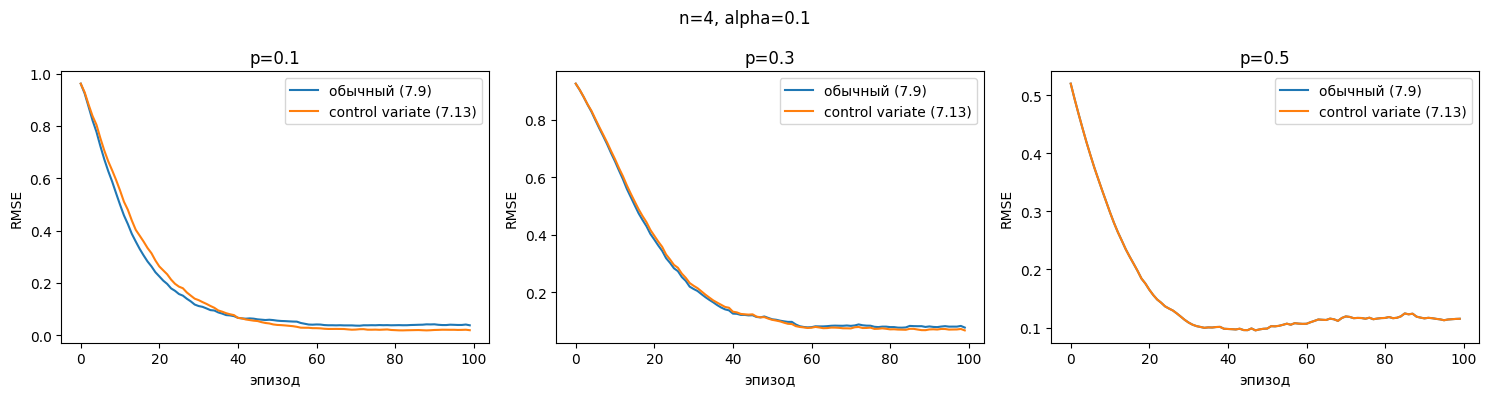

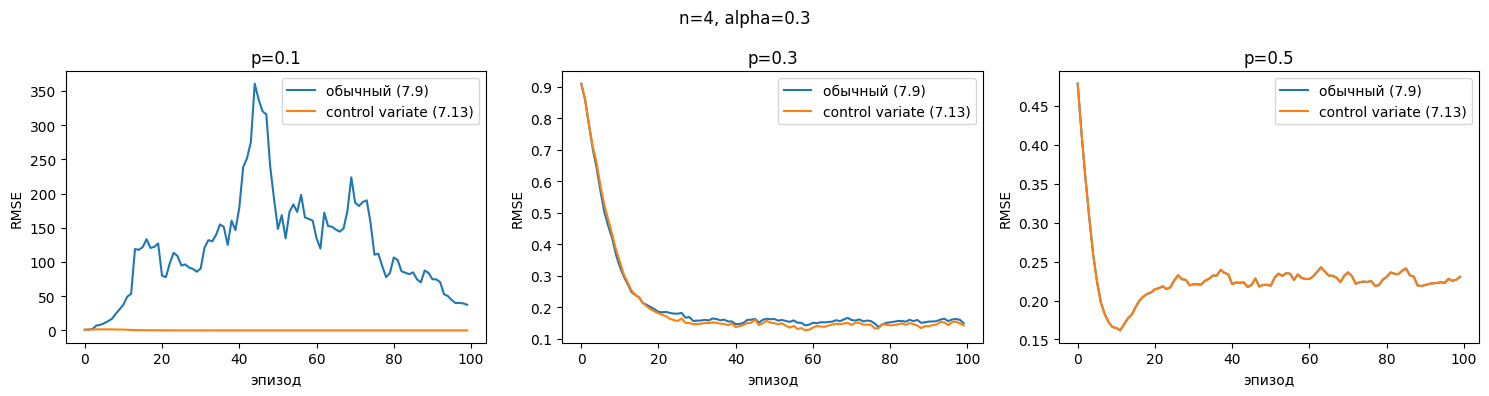

In [7]:
for alpha in (0.1, 0.3):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    for ax, p in zip(axes, PS):
        ax.plot(results[(alpha, p, False)], label="обычный (7.9)")
        ax.plot(results[(alpha, p, True)], label="control variate (7.13)")
        ax.set_title(f"p={p}")
        ax.set_xlabel("эпизод")
        ax.set_ylabel("RMSE")
        ax.legend()
    fig.suptitle(f"n={N_STEP}, alpha={alpha}")
    plt.tight_layout()
    plt.show()

При $\alpha=0.3$ обычный метод для $p=0.1$ может улетать в огромные значения --
смотрим в лог-масштабе, чтобы увидеть это явно.

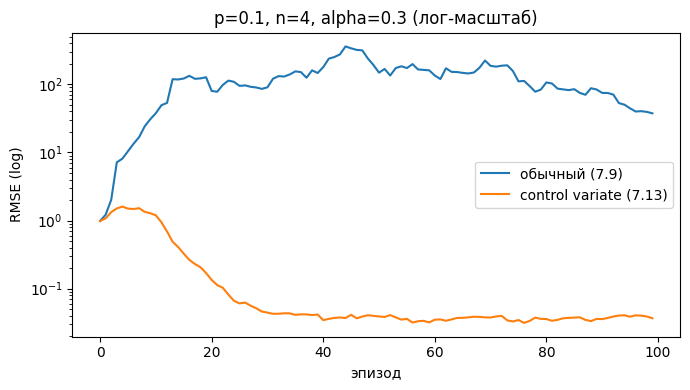

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results[(0.3, 0.1, False)], label="обычный (7.9)")
ax.plot(results[(0.3, 0.1, True)], label="control variate (7.13)")
ax.set_yscale("log")
ax.set_title("p=0.1, n=4, alpha=0.3 (лог-масштаб)")
ax.set_xlabel("эпизод")
ax.set_ylabel("RMSE (log)")
ax.legend()
plt.tight_layout()
plt.show()

## Выводы

* При $p=0.5$ (on-policy) кривые совпадают -- веса равны 1, методы тождественны.
* При смещении $\pi$ влево коэффициенты $\rho$ начинают сильно отличаться от 1,
  и на окне $n=4$ их произведения разлетаются в широком диапазоне. У обычного
  метода это даёт большую дисперсию обновлений, особенно при большом $\alpha$.
* Control variate усекает доход до текущей оценки $V$ в тех точках, где $\rho$
  мал, поэтому ведёт себя устойчиво даже там, где обычный метод расходится.

Вывод: при сильном расхождении $\pi$ и $b$ алгоритм с control variate (7.13)+(7.2)
заметно лучше обычного (7.1)+(7.9) -- он точнее и не разваливается при больших шагах.